In [11]:
import pandas as pd
import numpy as np    
import seaborn as sns
import matplotlib.pyplot as plt 

In [12]:
file_path = r"C:\Users\Max\Desktop\Dataset for Data Analytics.xlsx"
df = pd.read_excel(file_path)
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [13]:
print("--- Initial Inspection ---")
print(f"Total Rows before cleaning: {len(df)}")
print(f"Missing values per column:\n{df.isnull().sum()}\n")

--- Initial Inspection ---
Total Rows before cleaning: 1200
Missing values per column:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64



In [14]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df = df.dropna(subset=['OrderID', 'CustomerID'])

In [15]:
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates(keep='first')
    print(f"-> Removed {duplicate_count} duplicate row(s).")
else:
    print("-> No duplicate rows detected.")

-> No duplicate rows detected.


In [16]:
string_columns = df.select_dtypes(include=['object']).columns
for col in string_columns:
    df[col] = df[col].astype(str).str.strip()

In [17]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype(int)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce').round(2)

In [18]:
print(df.describe(include='all'))
print("Mean Quantity:", df['Quantity'].mean())
print("Median Quantity:", df['Quantity'].median())
print("Mode Quantity:", df['Quantity'].mode()[0])

C:\Users\Max\AppData\Local\Temp/ipykernel_38724/2478895205.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  print(df.describe(include='all'))


          OrderID                 Date CustomerID  Product     Quantity  \
count        1200                 1200       1200     1200  1200.000000   
unique       1200                  671       1189        7          NaN   
top     ORD200000  2023-08-20 00:00:00     C38840  Printer          NaN   
freq            1                    8          2      181          NaN   
first         NaN  2023-01-01 00:00:00        NaN      NaN          NaN   
last          NaN  2025-06-30 00:00:00        NaN      NaN          NaN   
mean          NaN                  NaN        NaN      NaN     2.945833   
std           NaN                  NaN        NaN      NaN     1.407557   
min           NaN                  NaN        NaN      NaN     1.000000   
25%           NaN                  NaN        NaN      NaN     2.000000   
50%           NaN                  NaN        NaN      NaN     3.000000   
75%           NaN                  NaN        NaN      NaN     4.000000   
max           NaN        

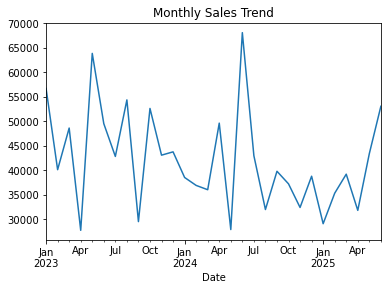

In [19]:
df.groupby(df['Date'].dt.to_period("M"))['TotalPrice'].sum().plot(kind='line', title="Monthly Sales Trend")
plt.show()

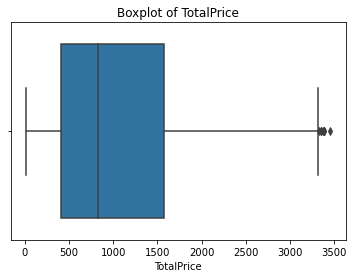

In [20]:
sns.boxplot(x=df['TotalPrice'])
plt.title("Boxplot of TotalPrice")
plt.show()

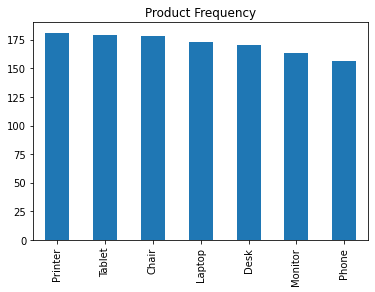

In [21]:
df['Product'].value_counts().plot(kind='bar', title="Product Frequency")
plt.show()

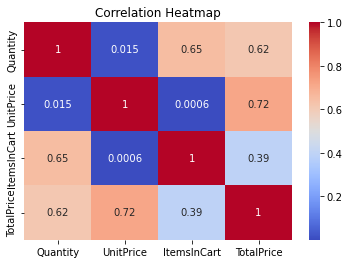

In [22]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()